In [1]:
# we need to read frames
# so we install opencv-python - change the next cell type to "Code"
# This file is from https://github.com/OpenPIV/openpiv-python-examples/blob/main/notebooks/analyse_movie.ipynb

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from openpiv import pyprocess, validation, filters, piv
import scipy.signal
from scipy import ndimage
from scipy import ndimage as ndi

In [3]:
# Test it by making another gif from the .nc files, using ~/Box for Hanna-Brian generality
# Since they have no time dimension, we need a trick to open them as a mfdataset

import glob
import os

# Expand the tilde to the home directory
pattern = os.path.expanduser('~/Box/GWaves_2023_10_11-14_SEPAC/VIS/Data/VIS_2023_10_13*')

# Get list of files
files = sorted(glob.glob(pattern))

# Open each file and add a new 'time' coordinate
datasets = [xr.open_dataset(f).assign_coords(time=i) for i, f in enumerate(files)]

# Concatenate along the new 'time' dimension
ds = xr.concat(datasets, dim='time')

ds

<xarray.Dataset> Size: 95MB
Dimensions:    (time: 14, latitude: 1125, longitude: 1500)
Coordinates:
  * latitude   (latitude) float32 4kB 9.94 9.9 9.86 ... -34.94 -34.98 -35.02
  * longitude  (longitude) float32 6kB -129.9 -129.9 -129.9 ... -70.02 -69.98
  * time       (time) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
Data variables:
    Rad        (time, latitude, longitude) float32 94MB nan nan ... 66.74 78.8
Attributes: (12/29)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           RBU
    ...                        ...
    date_created:              2023-10-13T14:29:56.1Z
    time_coverage_start:       2023-10-13T14:20:20.9Z
    time_coverage_end:         2023-10-13T14:29:51.8Z
    LUT_Filenames:             SpaceLookParams(FM1A_ADR1270_PR_12_02_01)-7371...
    id:                        68a174cb-b605-43e5-bff6-26cecb9c53c8
    history:                   2024-10-26 06:33:38: Resampled to regular lat-...

In [4]:
# dataset1 = xr.open_dataset('/Users/hannachaja/Documents/Research/PIV/synthetic/creations/Allen/IR_2023_10_12_03_15.nc')
# dataset2 = xr.open_dataset('/Users/hannachaja/Documents/Research/PIV/synthetic/creations/Allen/IR_2023_10_12_03_45.nc') 


###### BOX FOLDER #############
dataset1 = xr.open_dataset('~/Box/GWaves_2023_10_11-14_SEPAC/IR/Data/IR_2023_10_12_03_15.nc')
dataset2 = xr.open_dataset('~/Box/GWaves_2023_10_11-14_SEPAC/IR/Data/IR_2023_10_12_03_45.nc') 

In [5]:
dataarray1 = dataset1.to_array().squeeze()
dataarray2 = dataset2.to_array().squeeze()

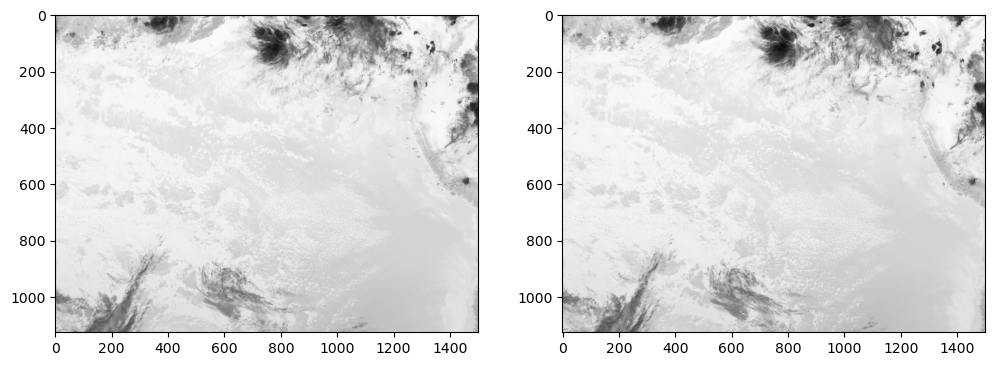

In [6]:
fig,ax = plt.subplots(1,2,figsize=(12,10))
ax[0].imshow(dataarray1,cmap=plt.cm.gray);
ax[1].imshow(dataarray2,cmap=plt.cm.gray);

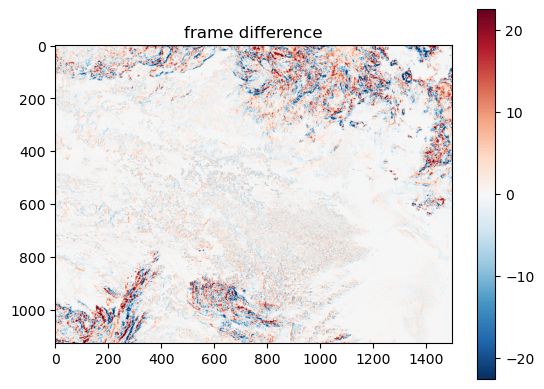

In [7]:
diff = dataarray2 - dataarray1
plt.imshow(diff, cmap="RdBu_r",
           vmin=-np.nanpercentile(np.abs(diff),99),
           vmax= np.nanpercentile(np.abs(diff),99))
plt.colorbar()
plt.title("frame difference")
plt.show()

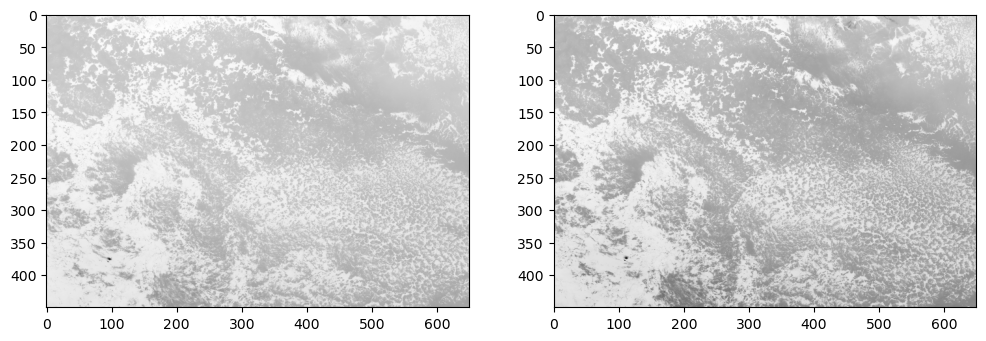

In [8]:
y0, y1 = 400, 850
x0, x1 = 450, 1100

# crop by positional index along latitude, longitude
dataarray1 = dataarray1.isel(latitude=slice(y0, y1), longitude=slice(x0, x1))
dataarray2 = dataarray2.isel(latitude=slice(y0, y1), longitude=slice(x0, x1))
fig,ax = plt.subplots(1,2,figsize=(12,10))
ax[0].imshow(dataarray1,cmap=plt.cm.gray);
ax[1].imshow(dataarray2,cmap=plt.cm.gray);

In [9]:
smoothed_image = ndimage.gaussian_filter(dataarray1, sigma=2) ########## USE 12 for synthetic
smoothed_image2 = ndimage.gaussian_filter(dataarray2, sigma=2)

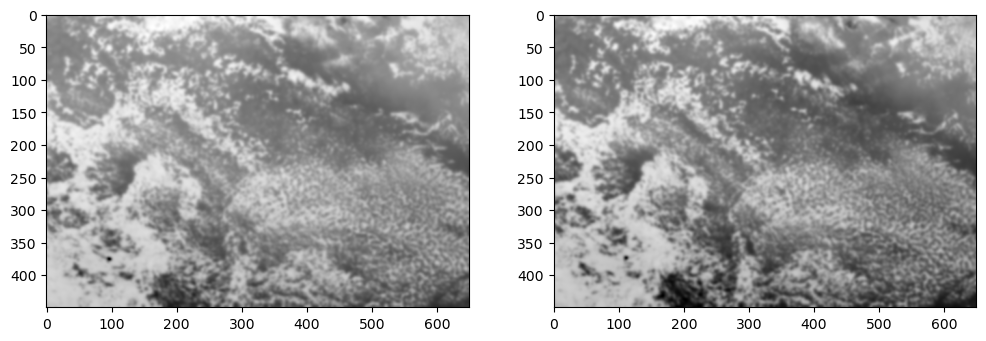

In [10]:
fig,ax = plt.subplots(1,2,figsize=(12,10))
ax[0].imshow(smoothed_image,cmap=plt.cm.gray);
ax[1].imshow(smoothed_image2,cmap=plt.cm.gray);

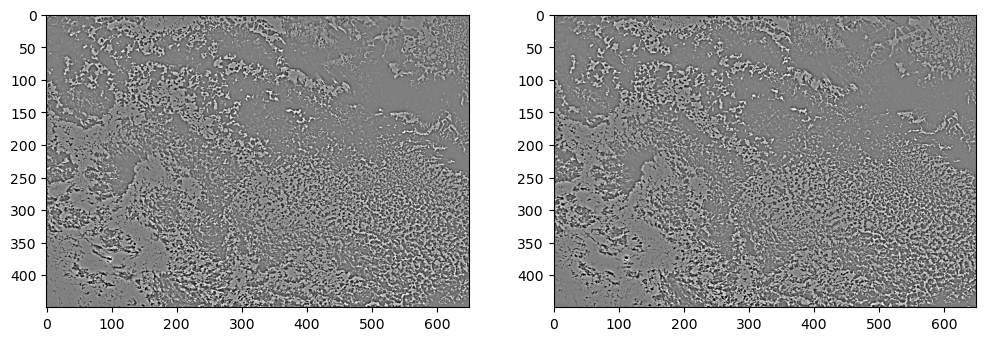

In [11]:
img1 = dataarray1-smoothed_image
img2 = dataarray2-smoothed_image2

fig,ax = plt.subplots(1,2,figsize=(12,10))
ax[0].imshow(img1,cmap=plt.cm.gray, vmin=-5, vmax=5);
ax[1].imshow(img2,cmap=plt.cm.gray, vmin=-5, vmax=5); 


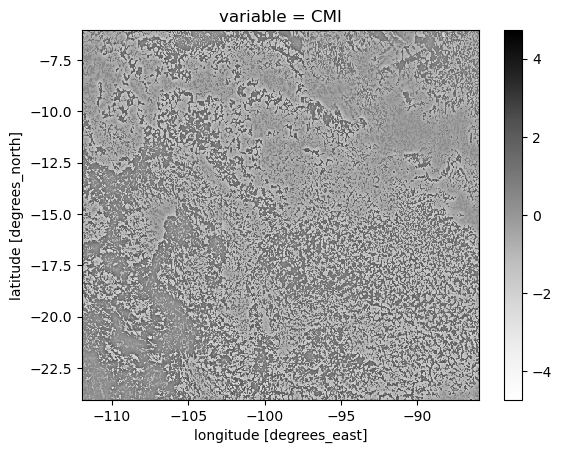

In [12]:
i1 = np.sqrt(np.abs(img1))*np.sign(img1)
i2 = np.sqrt(np.abs(img2))*np.sign(img2)
i2.plot(cmap='Greys')

In [13]:
# one.plot(cmap='Greys')

In [14]:
hp1 = xr.DataArray(i1, coords=dataarray1.coords, dims=dataarray1.dims, name='Rad_hp')
hp2 = xr.DataArray(i2, coords=dataarray2.coords, dims=dataarray2.dims, name='Rad_hp')

In [15]:
def stats(name, a):
    import numpy as np
    print(name, "shape", a.shape, "dtype", a.dtype,
          "min/max", np.nanmin(a), np.nanmax(a),
          "nan#", np.isnan(a).sum())

stats("img1", img1); stats("img2", img2)
stats("hp1", hp1);  stats("hp2", hp2)
print("hp1-hp2 mean abs:", np.nanmean(np.abs(hp1 - hp2)))

img1 shape (450, 650) dtype float32 min/max -25.718292 8.000763 nan# <xarray.DataArray ()> Size: 8B
array(0)
Coordinates:
    variable  <U3 12B 'CMI'
img2 shape (450, 650) dtype float32 min/max -22.387177 7.535248 nan# <xarray.DataArray ()> Size: 8B
array(0)
Coordinates:
    variable  <U3 12B 'CMI'
hp1 shape (450, 650) dtype float32 min/max -5.0713205 2.828562 nan# <xarray.DataArray 'Rad_hp' ()> Size: 8B
array(0)
Coordinates:
    variable  <U3 12B 'CMI'
hp2 shape (450, 650) dtype float32 min/max -4.7315087 2.7450407 nan# <xarray.DataArray 'Rad_hp' ()> Size: 8B
array(0)
Coordinates:
    variable  <U3 12B 'CMI'
hp1-hp2 mean abs: 1.1897762


In [16]:
frame_a = hp1.values.astype(np.float32)
frame_b = hp2.values.astype(np.float32)

# Optional: normalize for better PIV performance
# frame_a = (frame_a - frame_a.min()) / (frame_a.max() - frame_a.min())
# frame_b = (frame_b - frame_b.min()) / (frame_b.max() - frame_b.min())

In [17]:
window_size = 32   #was 32
search_size = 32   # was 32
overlap =  24  #was 18
dt = 1  # By having dt=1, units are pixels per frame, not seconds


u, v, sig2noise = pyprocess.extended_search_area_piv(
    frame_a.astype(np.float32),
    frame_b.astype(np.float32),
    window_size=window_size,
    overlap=overlap,
    dt=dt,
    search_area_size=search_size,
    sig2noise_method='peak2peak'
)

In [18]:
print("u range:", np.nanmin(u), np.nanmax(u))
print("v range:", np.nanmin(v), np.nanmax(v))

u range: -5.628766089677811 13.374235898256302
v range: -2.508165419101715 1.2501841187477112


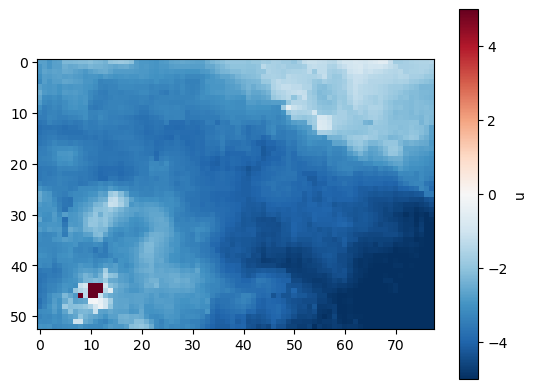

In [19]:
plt.imshow(u, vmin=-5, vmax=5, cmap='RdBu_r')
plt.colorbar(label="u")
# plt.yscale(

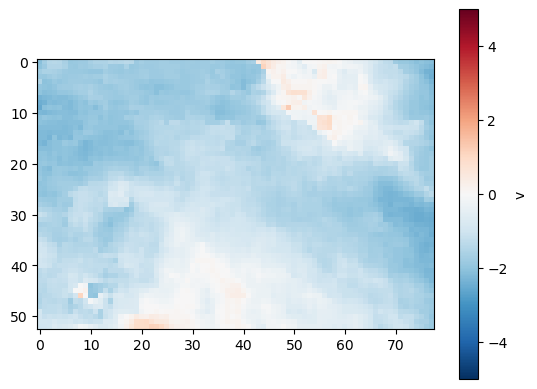

In [20]:
plt.imshow(v, vmin=-5, vmax=5, cmap='RdBu_r')
plt.colorbar(label="v")

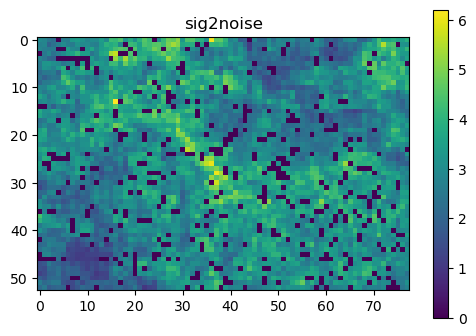

In [21]:
plt.figure(figsize=(6,4))
plt.imshow(sig2noise); plt.colorbar()
plt.title("sig2noise")
plt.show()

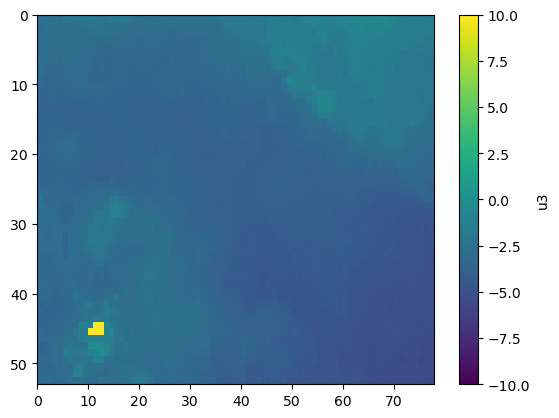

In [24]:
invalid_mask = validation.sig2noise_val(u, v,
    sig2noise,
    threshold = 1.15,       ################# USE 1.05 for synthetic ##############################
)


u3, v3 = filters.replace_outliers(
    u, v, invalid_mask,
    method='localmean',
    max_iter=3,
    kernel_size=5,
)

plt.pcolormesh(u3, vmin=-10, vmax=10)
plt.gca().invert_yaxis() 
plt.colorbar(label="u3")

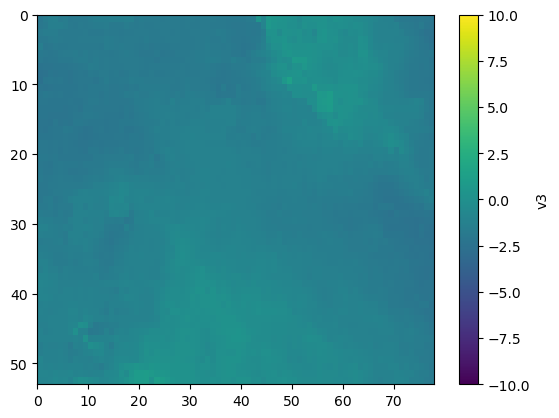

In [25]:
plt.pcolormesh(v3, vmin=-10, vmax=10)
plt.gca().invert_yaxis() 
plt.colorbar(label="v3")

In [28]:
for name,a in {"u3":u3,"v3":v3}.items():
    print(name, "p1–p99:", np.nanpercentile(a,[1,99]))

u3 p1–p99: [-5.2897953  -1.03808657]
v3 p1–p99: [-2.30581055  0.3602    ]


In [31]:
# ################ FIGURE OUR METERS PER PIXEL ##################################
# R = 6_371_000.0  # Earth radius (m)

# def haversine(lat1, lon1, lat2, lon2):
#     lat1, lon1, lat2, lon2 = map(np.deg2rad, (lat1, lon1, lat2, lon2))
#     dlat = lat2 - lat1
#     dlon = lon2 - lon1
#     a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
#     return 2*R*np.arcsin(np.sqrt(a))

# def dx_dy_from_coords(lat, lon):
#     lat = np.asarray(lat); lon = np.asarray(lon)

#     # 1D coordinates (regular grid)
#     if lat.ndim == 1 and lon.ndim == 1:
#         # center index
#         i = len(lat)//2
#         j = len(lon)//2
#         # neighbors (clamp to edges)
#         i2 = min(i+1, len(lat)-1); j2 = min(j+1, len(lon)-1)
#         dy = haversine(lat[i], lon[j], lat[i2], lon[j])     # N–S step (m/px)
#         dx = haversine(lat[i], lon[j], lat[i],   lon[j2])   # E–W step (m/px)
#         return float(dx), float(dy)

#     # 2D / curvilinear coordinates
#     # take center row/col and median neighbor spacing to be robust
#     ny, nx = lat.shape
#     ic, jc = ny//2, nx//2

#     # center column: dy along y
#     dy_line = haversine(lat[:-1, jc], lon[:-1, jc], lat[1:, jc], lon[1:, jc])
#     # center row: dx along x
#     dx_line = haversine(lat[ic, :-1], lon[ic, :-1], lat[ic, 1:], lon[ic, 1:])

#     dy = float(np.nanmedian(dy_line))
#     dx = float(np.nanmedian(dx_line))
#     return dx, dy

# # ---- use with your dataset ----
# # If your grid is 1D (most GOES-like):
# dx, dy = dx_dy_from_coords(ds.latitude.values, ds.longitude.values)
# print(f"dx = {dx:,.1f} m/px, dy = {dy:,.1f} m/px")

shape: (53, 78) dtype: float64
min/max: -0.004250563567297327 0.004200406304337803
p50/p90/p95/p99: [3.84825489e-06 1.07529551e-04 1.59559809e-04 2.92665551e-04]
nan count: 0
div p50/p90/p95/p99: [3.84825489e-06 1.07529551e-04 1.59559809e-04 2.92665551e-04]


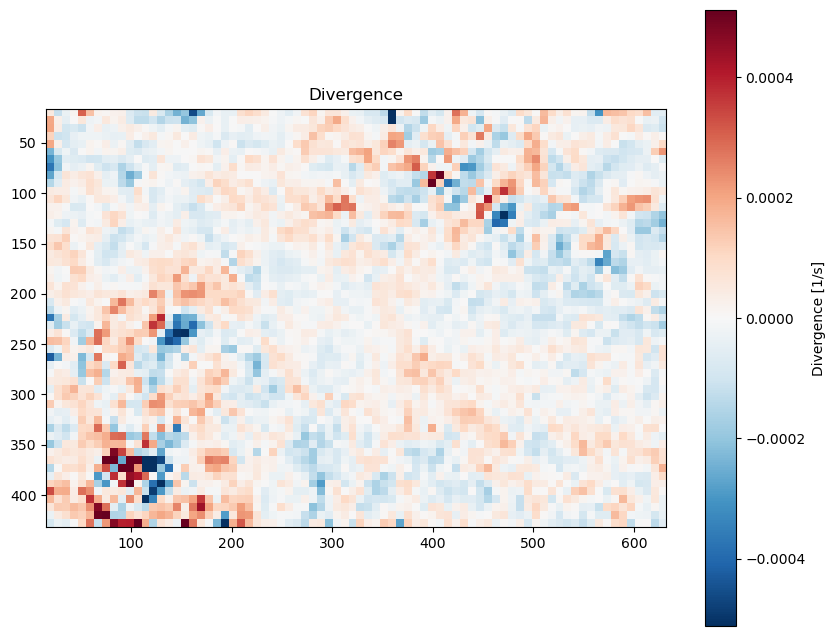

In [32]:
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import SymLogNorm
dx_m = 4342.0   # m/px  
dy_m = 4447.0   # m/px  

# real dt between the two frames (seconds)
dt_sec = 1800 #sec

# convert px/frame -> m/s
u_ms = u3 * dx_m / dt_sec
v_ms = v3 * dy_m / dt_sec


div = np.gradient(u_ms, dy_m, dx_m)[1] + np.gradient(v_ms, dy_m, dx_m)[0]   # s^-1 (u,v in m/s; dx,dy in m)

A = div  # or div_stack[i]

print("shape:", A.shape, "dtype:", A.dtype)
print("min/max:", np.nanmin(A), np.nanmax(A))
print("p50/p90/p95/p99:", np.nanpercentile(A, [50,90,95,99]))
print("nan count:", np.isnan(A).sum())

vmax = np.nanpercentile(np.abs(div), 99.5)   # 99–99.7 are typical
norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

# Coordinates of PIV grid in pixel units
x_px, y_px = pyprocess.get_coordinates(img1.shape, window_size, overlap, search_size)
extent = [x_px.min(), x_px.max(), y_px.max(), y_px.min()]   # origin='upper'

plt.figure(figsize=(10,8))
plt.imshow(div, origin='upper', cmap='RdBu_r', norm=norm, extent=extent)
plt.colorbar(label='Divergence [1/s]')
plt.title("Divergence")
print("div p50/p90/p95/p99:", np.nanpercentile(div, [50,90,95, 99]))

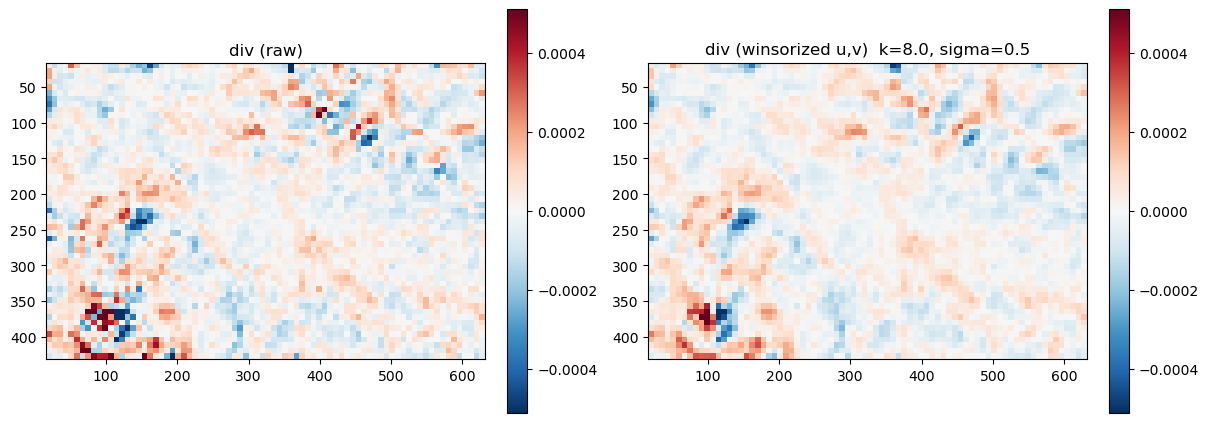

shape: (53, 78) dtype: float64
min/max: -0.0029143415133340107 0.0029969708465313652
p50/p90/p95/p99: [4.06160847e-06 9.15951045e-05 1.26702931e-04 2.20491888e-04]
nan count: 0


In [33]:
from scipy.ndimage import median_filter, gaussian_filter
# --- Robust "soft" outlier control on velocities (no discontinuous replacement) ---
u_in = u_ms.copy()
v_in = v_ms.copy()

u_med = median_filter(u_in, size=3, mode="nearest")
v_med = median_filter(v_in, size=3, mode="nearest")

ru = u_in - u_med
rv = v_in - v_med

mad_u = np.nanmedian(np.abs(ru - np.nanmedian(ru))); mad_u = mad_u if mad_u > 0 else 1e-12
mad_v = np.nanmedian(np.abs(rv - np.nanmedian(rv))); mad_v = mad_v if mad_v > 0 else 1e-12

k = 8.0     # try 6–12 (smaller = stronger clipping)
sigma = 0.5 # try 0, 0.3, 0.5, 0.7

# Winsorize residuals toward local median (continuous)
u_fix = u_med + np.clip(ru, -k*mad_u, k*mad_u)
v_fix = v_med + np.clip(rv, -k*mad_v, k*mad_v)

# Optional light smoothing before derivatives
if sigma and sigma > 0:
    u_fix = gaussian_filter(u_fix, sigma=sigma, mode="nearest")
    v_fix = gaussian_filter(v_fix, sigma=sigma, mode="nearest")

# Recompute divergence
div_raw = div.copy()
div_clip = np.gradient(u_fix, dy_m, dx_m)[1] + np.gradient(v_fix, dy_m, dx_m)[0]

# Plot comparison with same normalization (based on raw)
vmax = np.nanpercentile(np.abs(div_raw[np.isfinite(div_raw)]), 99.5)
norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
im0 = ax[0].imshow(div_raw, origin="upper", cmap="RdBu_r", norm=norm, extent=extent)
ax[0].set_title("div (raw)")
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(div_clip, origin="upper", cmap="RdBu_r", norm=norm, extent=extent)
ax[1].set_title(f"div (winsorized u,v)  k={k}, sigma={sigma}")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

plt.show()

# If you want to keep it downstream:
div = div_clip
A = div
print("shape:", A.shape, "dtype:", A.dtype)
print("min/max:", np.nanmin(A), np.nanmax(A))
print("p50/p90/p95/p99:", np.nanpercentile(A, [50,90,95,99]))
print("nan count:", np.isnan(A).sum())

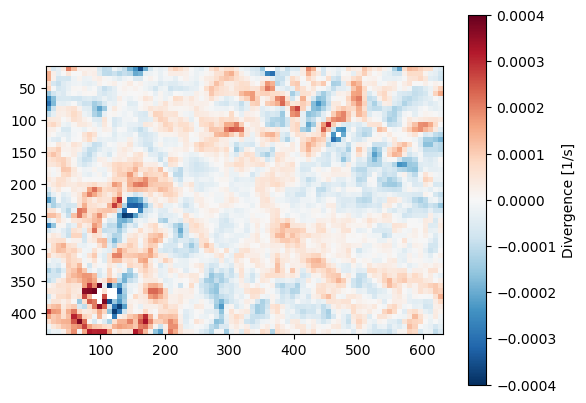

In [34]:
clip = 0.0004
div_masked = np.ma.masked_where(np.abs(div) > clip, div)

plt.imshow(div_masked, origin='upper', cmap='RdBu_r', vmin=-clip, vmax=clip, extent=extent)
plt.colorbar(label='Divergence [1/s]')

In [38]:
# #vlim = np.nanpercentile(np.abs(div), 99.5); vmin, vmax = -vlim, vlim
# fig, ax = plt.subplots(figsize=(10,8))
# plt.imshow(dataarray1, cmap='Greys')
# cs = plt.contour(x_px, y_px, div, origin='upper', cmap='RdBu_r', vmin=-1e-4, vmax=1e-4)

# #levels = np.linspace(-1e-4, 1e-4, 11)
# # plt.contour(x_px, y_px, div, levels=levels, origin='upper', cmap='RdBu_r', vmin=-1e-4, vmax=1e-4)
# print("vlim (99.5%):", np.nanpercentile(np.abs(div_masked), 99.5))
# print("imshow vmax:", 0.004)
# print("max abs div:", np.nanmax(np.abs(div_masked)))

# print(cs.levels)

In [39]:

Z = div
print("stack maxabs:", np.nanmax(np.abs(Z)))

stack maxabs: 0.0029969708465313652


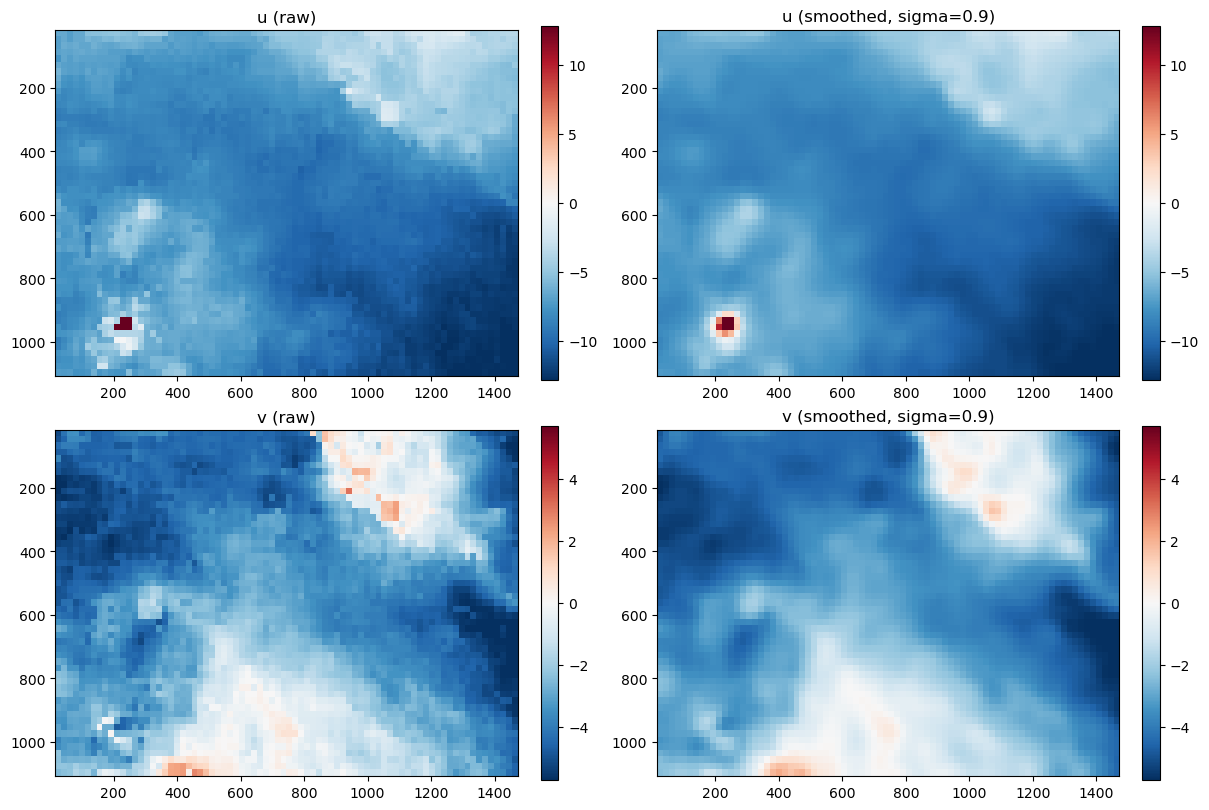

In [40]:

# --- parameters ---
sigma = 0.9   # same sigma as used for divergence-of-Gaussian

# --- original velocity fields (m/s) ---
u_raw = u_ms
v_raw = v_ms

# --- smoothed velocity fields ---
u_smooth = gaussian_filter(u_raw, sigma=sigma, mode="nearest")
v_smooth = gaussian_filter(v_raw, sigma=sigma, mode="nearest")

# --- common color limits (robust) ---
ulim = np.nanpercentile(np.abs(u_raw), 99)
vlim = np.nanpercentile(np.abs(v_raw), 99)

# --- plotting ---
fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

im0 = ax[0,0].imshow(u_raw, origin="upper", cmap="RdBu_r",
                     vmin=-ulim, vmax=ulim, extent=extent)
ax[0,0].set_title("u (raw)")
plt.colorbar(im0, ax=ax[0,0])

im1 = ax[0,1].imshow(u_smooth, origin="upper", cmap="RdBu_r",
                     vmin=-ulim, vmax=ulim, extent=extent)
ax[0,1].set_title(f"u (smoothed, sigma={sigma})")
plt.colorbar(im1, ax=ax[0,1])

im2 = ax[1,0].imshow(v_raw, origin="upper", cmap="RdBu_r",
                     vmin=-vlim, vmax=vlim, extent=extent)
ax[1,0].set_title("v (raw)")
plt.colorbar(im2, ax=ax[1,0])

im3 = ax[1,1].imshow(v_smooth, origin="upper", cmap="RdBu_r",
                     vmin=-vlim, vmax=vlim, extent=extent)
ax[1,1].set_title(f"v (smoothed, sigma={sigma})")
plt.colorbar(im3, ax=ax[1,1])

plt.show()

div p50/p90/p95/p99: [8.90903115e-06 1.87883157e-04 2.57156352e-04 4.51768362e-04]


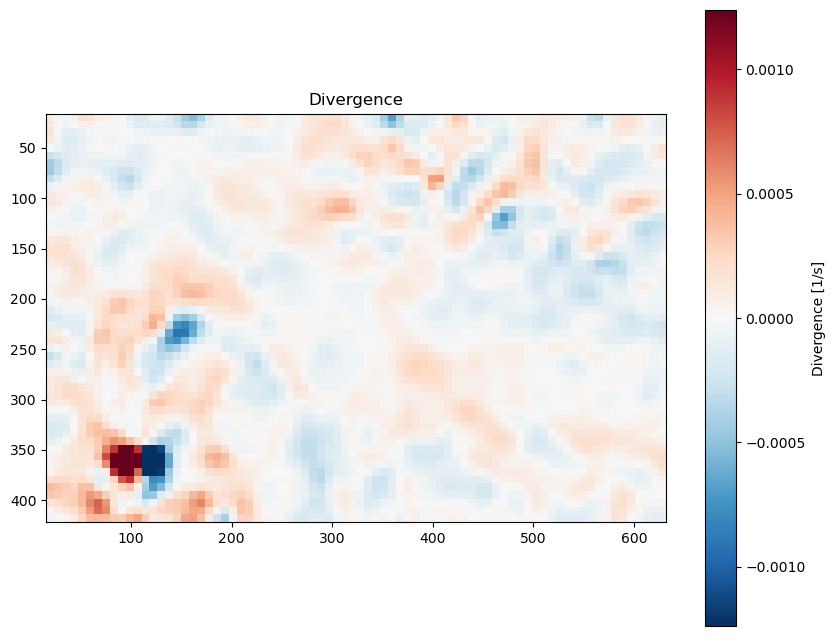

In [41]:
# convert px/frame -> m/s
u_ms = u_smooth * dx_m / dt_sec
v_ms = v_smooth * dy_m / dt_sec


div = np.gradient(u_ms, dy_m, dx_m)[1] + np.gradient(v_ms, dy_m, dx_m)[0]   # s^-1 (u,v in m/s; dx,dy in m)

vmax = np.nanpercentile(np.abs(div), 99.5)   # 99–99.7 are typical
norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

# Coordinates of PIV grid in pixel units
x_px, y_px = pyprocess.get_coordinates(img1.shape, window_size, overlap, search_size)
extent = [x_px.min(), x_px.max(), y_px.max(), y_px.min()]   # origin='upper'

plt.figure(figsize=(10,8))
plt.imshow(div, origin='upper', cmap='RdBu_r', norm=norm, extent=extent)
plt.colorbar(label='Divergence [1/s]')
plt.title("Divergence")
print("div p50/p90/p95/p99:", np.nanpercentile(div, [50,90,95, 99]))

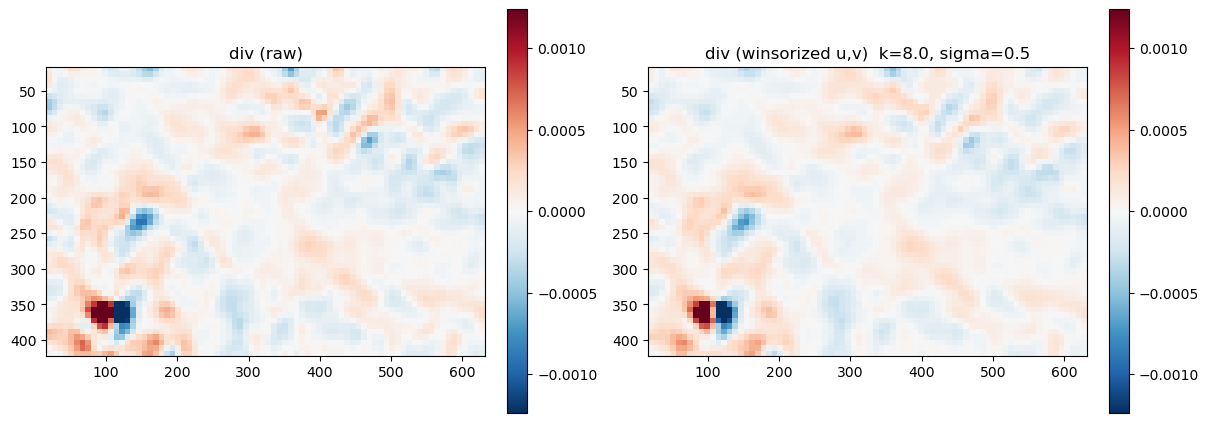

In [42]:

# --- Robust "soft" outlier control on velocities (no discontinuous replacement) ---
u_in = u_ms.copy()
v_in = v_ms.copy()

u_med = median_filter(u_in, size=3, mode="nearest")
v_med = median_filter(v_in, size=3, mode="nearest")

ru = u_in - u_med
rv = v_in - v_med

mad_u = np.nanmedian(np.abs(ru - np.nanmedian(ru))); mad_u = mad_u if mad_u > 0 else 1e-12
mad_v = np.nanmedian(np.abs(rv - np.nanmedian(rv))); mad_v = mad_v if mad_v > 0 else 1e-12

k = 8.0     # try 6–12 (smaller = stronger clipping)
sigma = 0.5 # try 0, 0.3, 0.5, 0.7

# Winsorize residuals toward local median (continuous)
u_fix = u_med + np.clip(ru, -k*mad_u, k*mad_u)
v_fix = v_med + np.clip(rv, -k*mad_v, k*mad_v)

# Optional light smoothing before derivatives
if sigma and sigma > 0:
    u_fix = gaussian_filter(u_fix, sigma=sigma, mode="nearest")
    v_fix = gaussian_filter(v_fix, sigma=sigma, mode="nearest")

# Recompute divergence
div_raw = div.copy()
div_clip = np.gradient(u_fix, dy_m, dx_m)[1] + np.gradient(v_fix, dy_m, dx_m)[0]

# Plot comparison with same normalization (based on raw)
vmax = np.nanpercentile(np.abs(div_raw[np.isfinite(div_raw)]), 99.5)
norm = TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
im0 = ax[0].imshow(div_raw, origin="upper", cmap="RdBu_r", norm=norm, extent=extent)
ax[0].set_title("div (raw)")
plt.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(div_clip, origin="upper", cmap="RdBu_r", norm=norm, extent=extent)
ax[1].set_title(f"div (winsorized u,v)  k={k}, sigma={sigma}")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

plt.show()

# If you want to keep it downstream:
div = div_clip


TypeError: Shapes of x (30, 45) and z (53, 78) do not match

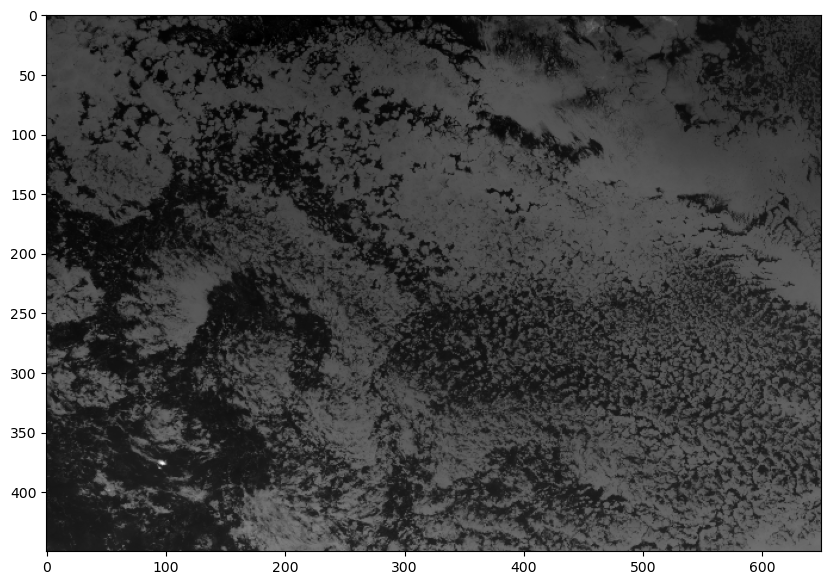

In [50]:

# #vlim = np.nanpercentile(np.abs(div), 99.5); vmin, vmax = -vlim, vlim
# fig, ax = plt.subplots(figsize=(10,8))
# plt.imshow(dataarray1, cmap='Greys')
# cs = plt.contour(x_px, y_px, div, origin='upper', cmap='RdBu_r', vmin=-1e-4, vmax=1e-4)

# #levels = np.linspace(-1e-4, 1e-4, 11)
# # plt.contour(x_px, y_px, div, levels=levels, origin='upper', cmap='RdBu_r', vmin=-1e-4, vmax=1e-4)

# print(cs.levels)

(array([[ 0.,  0.,  0.,  2., 50.,  1.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  2., 50.,  1.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., 51.,  2.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., 51.,  2.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., 49.,  4.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., 47.,  6.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., 44.,  9.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., 45.,  8.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0., 44.,  5.,  4.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  2., 40.,  7.,  1.,  1.,  1.,  1.],
        [ 0.,  0.,  0.,  2., 44.,  2.,  1.,  2.,  0.,  2.],
        [ 0.,  0.,  0.,  0., 48.,  5.,  0.,  0.,  0.,  0.],
        [ 1.,  2.,  1.,  3., 45.,  1.,  0.,  0.,  0.,  0.],
        [ 2.,  2.,  1.,  6., 41.,  1.,  0.,  0.,  0.,  0.],
        [ 2.,  0.,  2.,  8., 41.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0., 12., 41.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  8., 41.,  4.,  

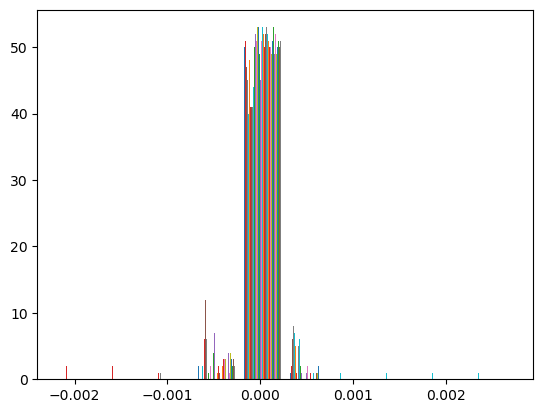

In [47]:
plt.hist(div)

Divergence stats [s^-1]:
 min=-2.208e-03  max=2.753e-03
 p0.1=-1.765e-03  p1=-3.837e-04  p5=-1.945e-04  median=7.122e-06  p95=2.290e-04  p99=3.864e-04  p99.9=1.704e-03
Suggested colorbar limits for map: ±3.86e-04 s^-1


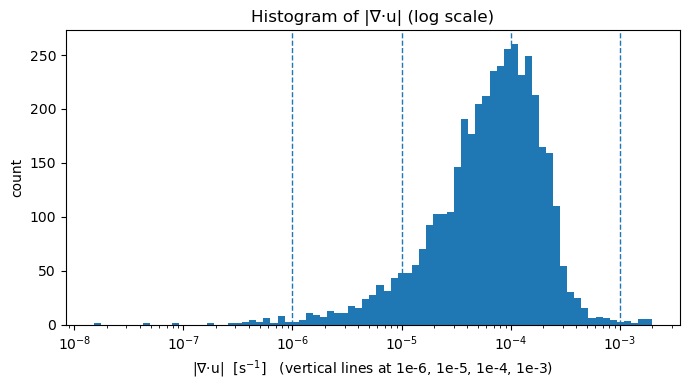

In [48]:
# --- Assume `divergence` is your 2-D array; may contain NaNs ---
div = np.asarray(div, dtype=float)

# Flatten + drop NaNs/Infs
vals = div[np.isfinite(div)].ravel()
if vals.size == 0:
    raise ValueError("No finite divergence values found.")

# Quick stats
p = np.percentile(vals, [0.1, 1, 5, 50, 95, 99, 99.9])
print("Divergence stats [s^-1]:")
print(f" min={vals.min():.3e}  max={vals.max():.3e}")
print(f" p0.1={p[0]:.3e}  p1={p[1]:.3e}  p5={p[2]:.3e}  median={p[3]:.3e}  p95={p[4]:.3e}  p99={p[5]:.3e}  p99.9={p[6]:.3e}")

# Suggested plotting limits based on robust range
vlim = float(np.max(np.abs(p[[4,5]])))   # use high percentiles to avoid outliers
print(f"Suggested colorbar limits for map: ±{vlim:.2e} s^-1")


# --- Histogram of absolute values on log10 scale (great for orders of magnitude) ---
abs_vals = np.abs(vals)
abs_vals = abs_vals[abs_vals > 0]  # drop zeros for log
plt.figure(figsize=(7,4))
log_bins = np.logspace(np.log10(abs_vals.min()), np.log10(np.percentile(abs_vals, 99.9)), 80)
plt.hist(abs_vals, bins=log_bins)
for lvl in [1e-6, 1e-5, 1e-4, 1e-3]:
    plt.axvline(lvl, ls='--', lw=1)
plt.xscale('log')
plt.title("Histogram of |∇·u| (log scale)")
plt.xlabel("|∇·u|  [s$^{-1}$]   (vertical lines at 1e-6, 1e-5, 1e-4, 1e-3)")
plt.ylabel("count")
plt.tight_layout()
plt.show()